## Demo 2: (WorkflowAware) deadline prioritization

In this demo we demonstrate how `WorkflowAware` scheduler respects workflow deadlines and pioritizes the tasks with smaller slack values!

In [38]:
import subprocess
from enum import Enum
from pathlib import Path

import pandas as pd
import plotly.express as px
import platform
import os
import plotly.graph_objects as go
import plotly.express as px
from PIL import Image

## Step 1: Generating Data

We prepare a simple workload consisting of 2 identical workflows.
Noteably, we make the second workflow's submission time a bit later than the first one's, but make its deadline much shorter!

(The data for this demo is already generated, so no need to rerun it)

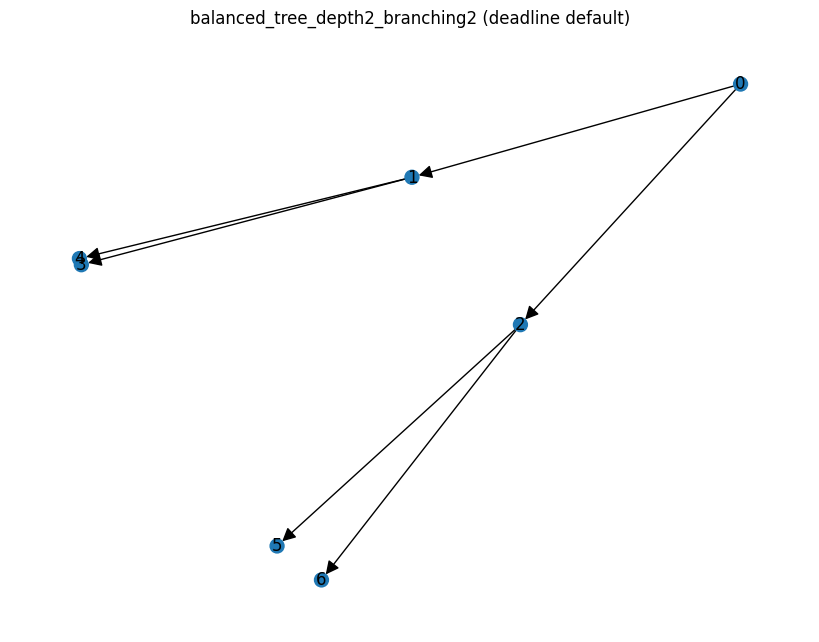

In [ ]:
seed = "../input/synthetic_traces/balanced_tree_depth2_branching2_deadline_default/"

seed_tasks = pd.read_parquet(seed + "tasks.parquet")
seed_fragments = pd.read_parquet(seed + "fragments.parquet")

dag_image = Image.open(seed + "dag.png")
dag_image

In [12]:
final_tasks = []
final_fragments = []

In [13]:
# regular stuff
final_tasks.append(seed_tasks.copy())
final_fragments.append(seed_fragments.copy())

for i in range(1):
    # increase ID's and submition times
    seed_tasks["id"] += 100
    seed_tasks["parents"] += 100
    seed_tasks["children"] += 100
    seed_tasks["submission_time"] += 10
    seed_tasks["deadline"] = seed_tasks["submission_time"] + 10
    seed_fragments["id"] += 100

    final_tasks.append(seed_tasks.copy())
    final_fragments.append(seed_fragments.copy())

In [ ]:
final_tasks_df = pd.concat(final_tasks).reset_index(drop=True)
final_fragments_df = pd.concat(final_fragments).reset_index(drop=True)

# final_tasks_df.to_parquet("demo_workloads/demo_2/tasks.parquet")
# final_fragments_df.to_parquet("demo_workloads/demo_2/fragments.parquet")

In [15]:
final_tasks_df["deadline"] - final_tasks_df["submission_time"]

0     60090000
1     60090000
2     60090000
3     60090000
4     60090000
5     60090000
6     60090000
7           10
8           10
9           10
10          10
11          10
12          10
13          10
dtype: int64

## Step 2: Running the workload

In [11]:
class SchedulerEnum(Enum):
    DEFAULT_SCHEDULER = 0
    WORKFLOW_AWARE_SCHEDULER = 1

In [12]:
# DETECT JAVA HOME

os_type = platform.system()

if os_type == "Darwin":  # macOS
    os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21"
    os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]
elif os_type == "Linux":  # Ubuntu/Linux
    java_home = os.environ.get("JAVA_HOME", "/usr/lib/jvm/java-21-openjdk-amd64")
    os.environ["JAVA_HOME"] = java_home
    os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]
else:
    print(
        f"Warning: Unsupported OS ({os_type}). JAVA_HOME may need to be set manually."
    )


In [13]:
experiment = "demo_experiments/demo_experiment_2.json"

subprocess.run(
    [
        "../OpenDCExperimentRunner/bin/OpenDCExperimentRunner",
        "--experiment-path",
        experiment,
    ]
)



 Running scenario: 0 
 Starting seed: 0 


Simulating...   0% [                                       ] 0/2 (0:00:00 / ?) 

Creating ComputeScheduler: Random with 1 hosts


 Running scenario: 1 
 Starting seed: 0 
Creating ComputeScheduler: WorkflowAware with 1 hosts


Simulating... 100% [=================================] 2/2 (0:00:00 / 0:00:00) 


CompletedProcess(args=['../OpenDCExperimentRunner/bin/OpenDCExperimentRunner', '--experiment-path', 'demo_experiments/demo_experiment_2.json'], returncode=0)

In [23]:
fig = go.Figure()

output_path = "output/demo_experiment/raw-output/{}/seed=0/"
for scheduler_type in SchedulerEnum:
    df_task = pd.read_parquet(output_path.format(scheduler_type.value) + "task.parquet")
    df_service = pd.read_parquet(
        output_path.format(scheduler_type.value) + "service.parquet"
    )

    # calculating metrics:
    runtime = pd.to_timedelta(
        df_service.timestamp.max() - df_service.timestamp.min(), unit="ms"
    )

    print(f"Scheduler: {scheduler_type.name}")
    print(f"The workload was finished in {runtime}")

    # print execution path
    print("Execution Path:")
    executed_tasks = (
        df_task.query("task_state == 'COMPLETED'")
        .sort_values("finish_time")["task_id"]
        .to_list()
    )

    print(executed_tasks)
    print("=" * 50 + "\n")

    fig.add_scatter(
        x=list(range(len(executed_tasks))),
        y=executed_tasks,
        mode="lines",
        name=scheduler_type.name,
    )

fig.update_layout(
    width=1000,
    height=400,
    title="Task Execution Order Comparison",
    xaxis_title="ticks",
    yaxis_title="Task ID",
)
fig.show()

Scheduler: DEFAULT_SCHEDULER
The workload was finished in 0 days 00:03:21
Execution Path:
[0, 100, 1, 2, 101, 102, 3, 4, 5, 6, 103, 104, 105, 106]

Scheduler: WORKFLOW_AWARE_SCHEDULER
The workload was finished in 0 days 00:03:21
Execution Path:
[0, 100, 1, 2, 101, 102, 103, 104, 105, 106, 3, 4, 5, 6]



We can see how the `WorkflowAware` scheduler priotizes the tasks of the second workflow given that it's deadline is much closer!